<a href="https://colab.research.google.com/github/Handinoasa/PCVK_2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import drive
import glob

# Mount Drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Inverse Citra

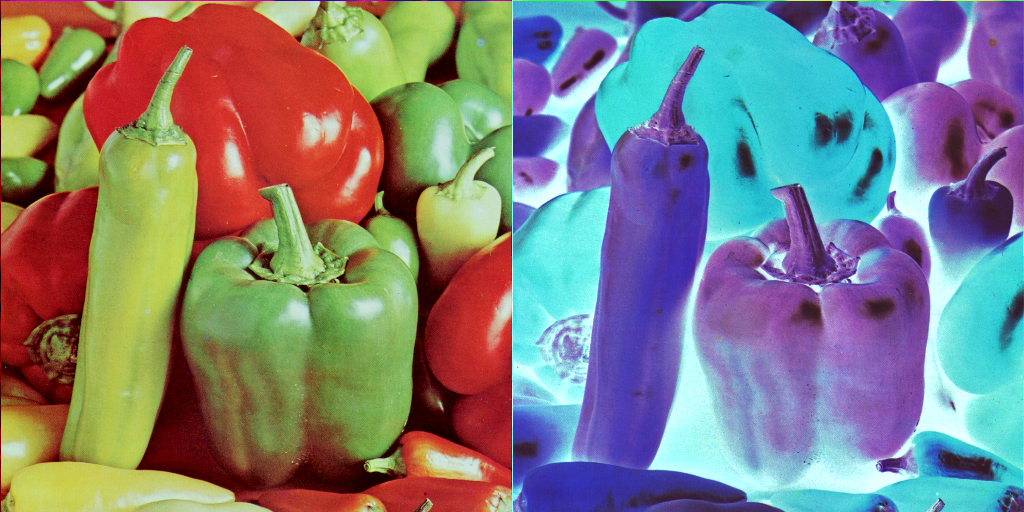

In [ ]:
img = cv.imread('/content/drive/MyDrive/Images/peppers.tiff')
# Implementasi Inverse
inverse_img = 255 - img

final_frame = cv.hconcat((img, inverse_img))
cv2_imshow(final_frame)

## 2. Transformasi Contrast

Masukkan tingkat kecerahan: 10
Masukkan kontras: 1.5


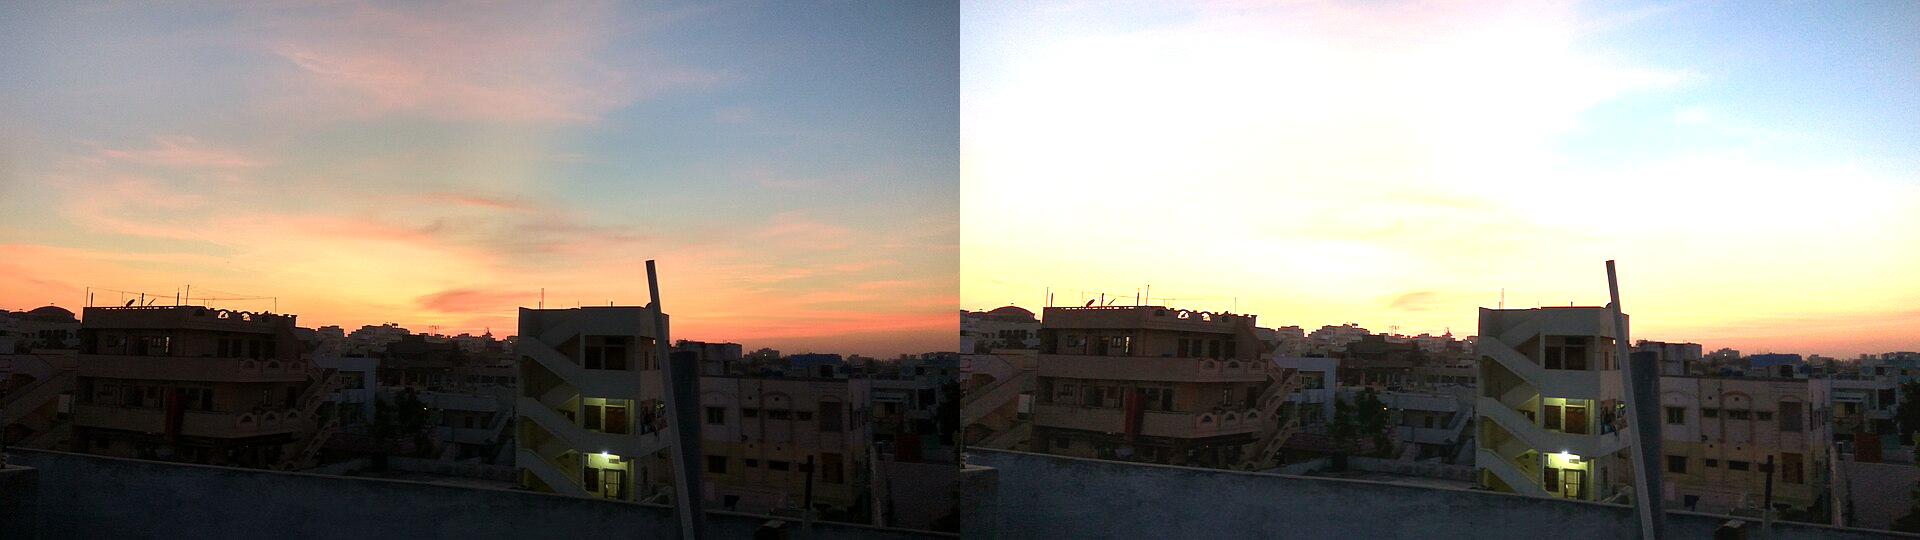

In [ ]:
img = cv.imread('/content/drive/MyDrive/Images/sunset.jpg')

kecerahan = int(input("Masukkan tingkat kecerahan: "))
kontras = float(input("Masukkan kontras: "))

# Menggunakan np.clip untuk menahan nilai (truncate) agar tetap di range 0-255
contrast_img = np.clip(kontras * img + kecerahan, 0, 255).astype(np.uint8)

final_frame = cv.hconcat((img, contrast_img))
cv2_imshow(final_frame)

## 3. Transformasi Logaritmathic Brightness

Masukkan nilai kecerahan (konstanta c): 50


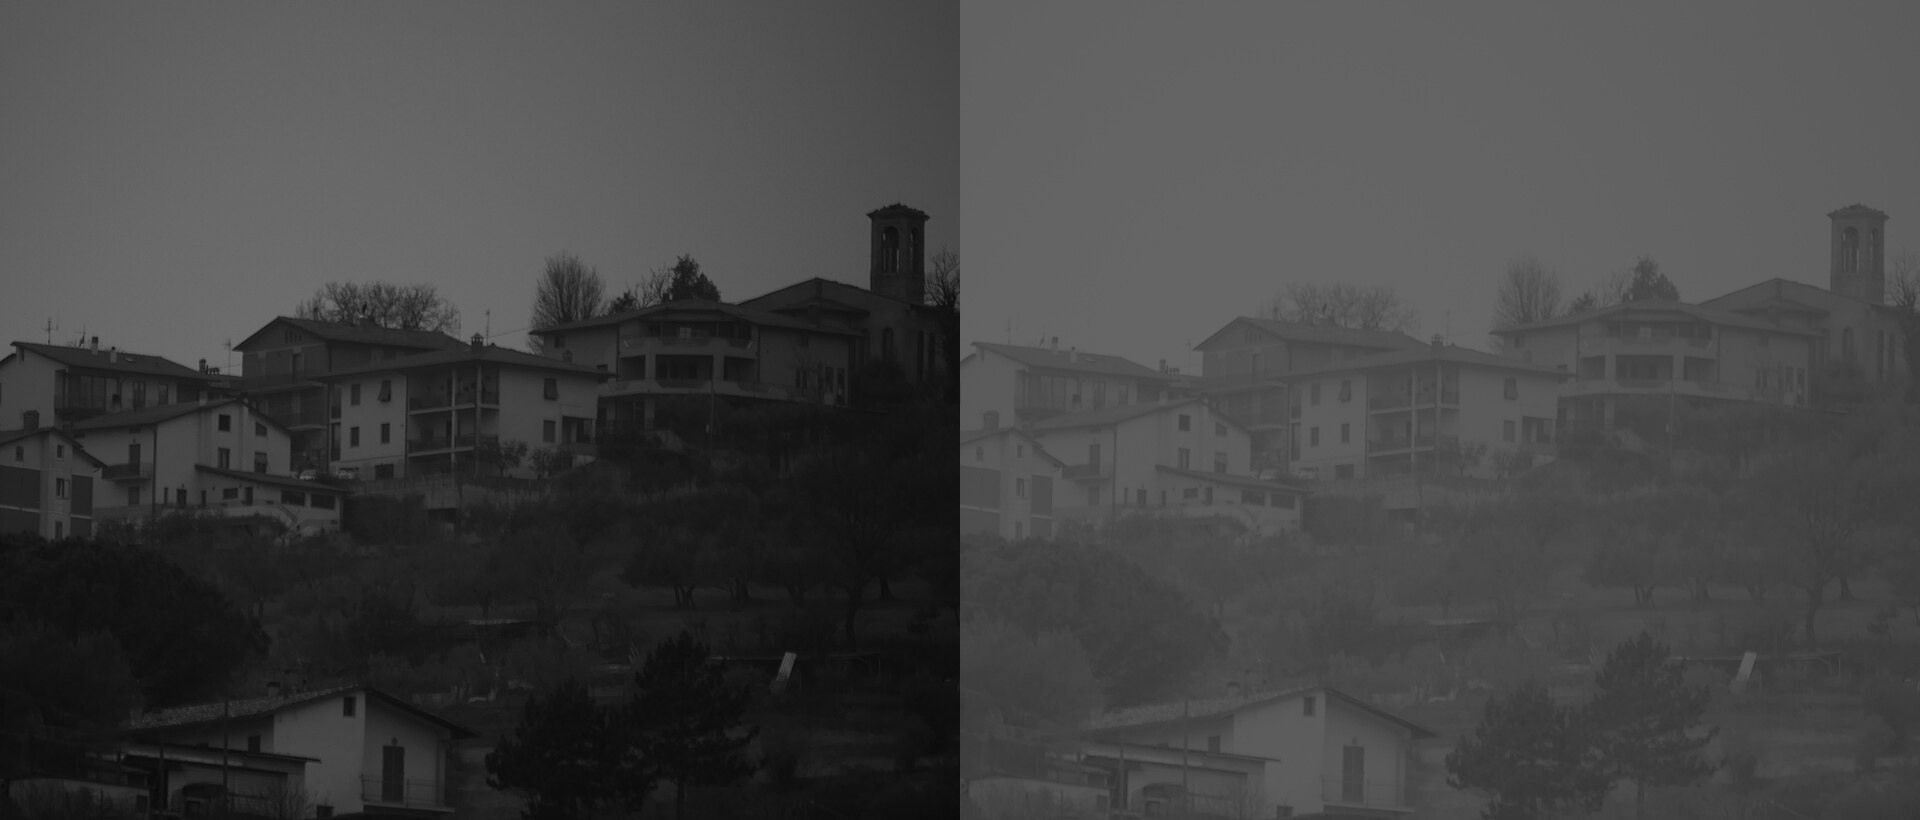

In [ ]:
img = cv.imread('/content/drive/MyDrive/Images/houses.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

kecerahan_log = int(input("Masukkan nilai kecerahan (konstanta c): "))

# Pastikan tipe data float untuk perhitungan log
img_float = np.float32(img_gray)
log_img = kecerahan_log * (np.log10(img_float + 1))

# Truncate dan kembalikan ke tipe uint8
log_img = np.clip(log_img, 0, 255).astype(np.uint8)

final_frame = cv.hconcat((img_gray, log_img))
cv2_imshow(final_frame)

## 4. Operasi Grayscale (Averaging, Lightness, Luminance)

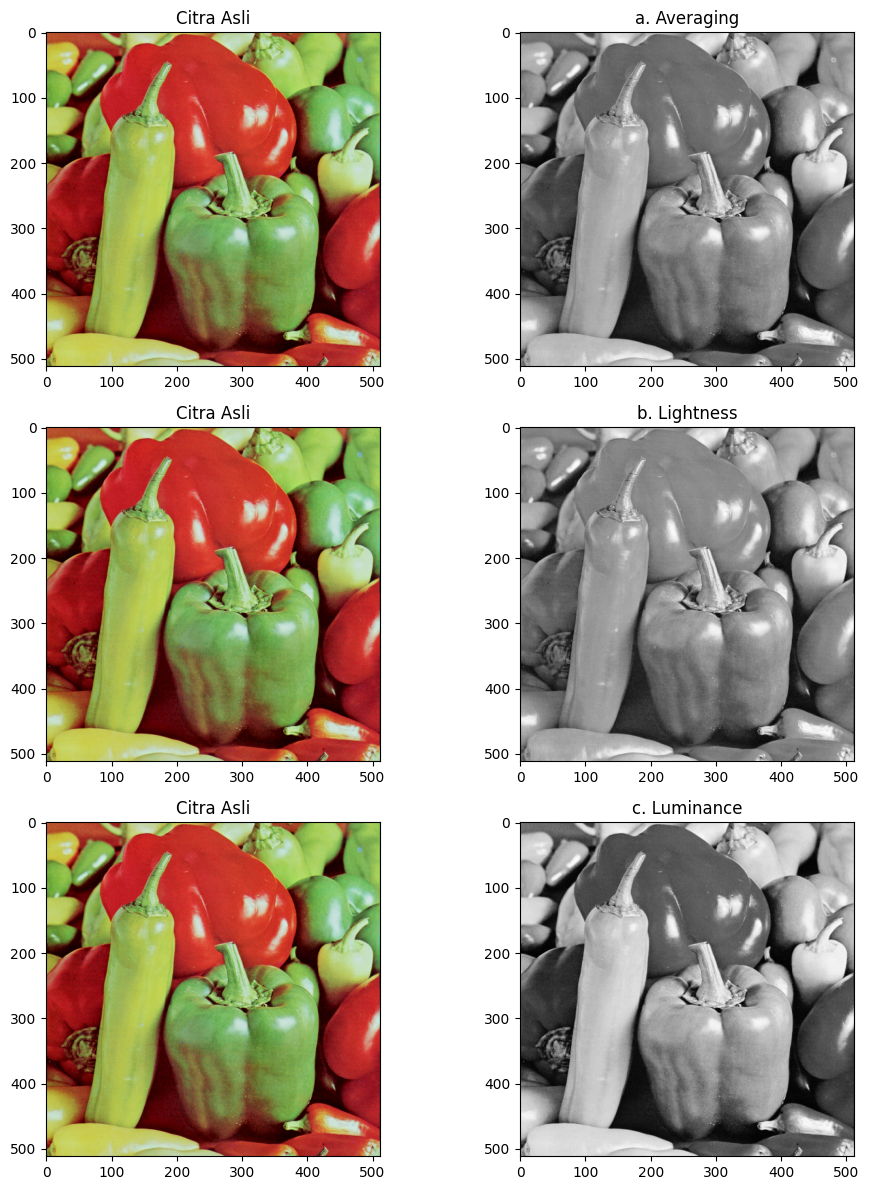

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Sesuaikan path gambar
path_gambar = '/content/drive/MyDrive/Images/peppers.tiff'
img = cv.imread(path_gambar)

if img is None:
    print(f"Gambar gagal dimuat! Cek kembali path ini: {path_gambar}")
else:
    # Konversi BGR (OpenCV) ke RGB (Matplotlib) untuk gambar asli
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    B, G, R = cv.split(img.astype(float))

    # a. Averaging: (R+G+B)/3
    avg_gray = ((R + G + B) / 3).astype(np.uint8)

    # b. Lightness: (max[R,G,B] + min[R,G,B])/2
    max_rgb = np.maximum(np.maximum(R, G), B)
    min_rgb = np.minimum(np.minimum(R, G), B)
    lightness_gray = ((max_rgb + min_rgb) / 2).astype(np.uint8)

    # c. Luminance: 0.21R + 0.72G + 0.07B
    luminance_gray = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

    # Menampilkan hasil (Grid 3 baris x 2 kolom)
    plt.figure(figsize=(10, 12))

    # --- Bagian A: Averaging ---
    plt.subplot(3, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Citra Asli')

    plt.subplot(3, 2, 2)
    plt.imshow(avg_gray, cmap='gray')
    plt.title('a. Averaging')

    # --- Bagian B: Lightness ---
    plt.subplot(3, 2, 3)
    plt.imshow(img_rgb)
    plt.title('Citra Asli')

    plt.subplot(3, 2, 4)
    plt.imshow(lightness_gray, cmap='gray')
    plt.title('b. Lightness')

    # --- Bagian C: Luminance ---
    plt.subplot(3, 2, 5)
    plt.imshow(img_rgb)
    plt.title('Citra Asli')

    plt.subplot(3, 2, 6)
    plt.imshow(luminance_gray, cmap='gray')
    plt.title('c. Luminance')

    # Merapikan jarak antar plot
    plt.tight_layout()
    plt.show()

## 5. Menampilkan Warna Tertentu (Masking Warna Merah)

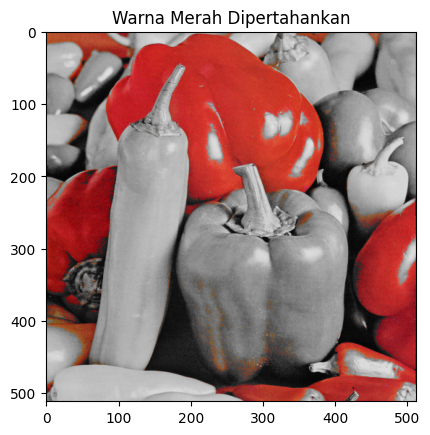

In [ ]:
img = cv.imread('/content/drive/MyDrive/Images/peppers.tiff')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img_gray_3ch = cv.cvtColor(img_gray, cv.COLOR_GRAY2RGB) # Jadikan 3 channel agar bisa digabung

# Masking sederhana: cari area di mana Red dominan
R, G, B = cv.split(img_rgb)
mask = (R > 120) & (G < 100) & (B < 100)

# Buat salinan grayscale, lalu timpa dengan warna asli HANYA pada area mask
result = img_gray_3ch.copy()
result[mask] = img_rgb[mask]

plt.imshow(result)
plt.title("Warna Merah Dipertahankan")
plt.show()

## 6. Gamma Correction

Masukkan nilai Gamma: 0.5


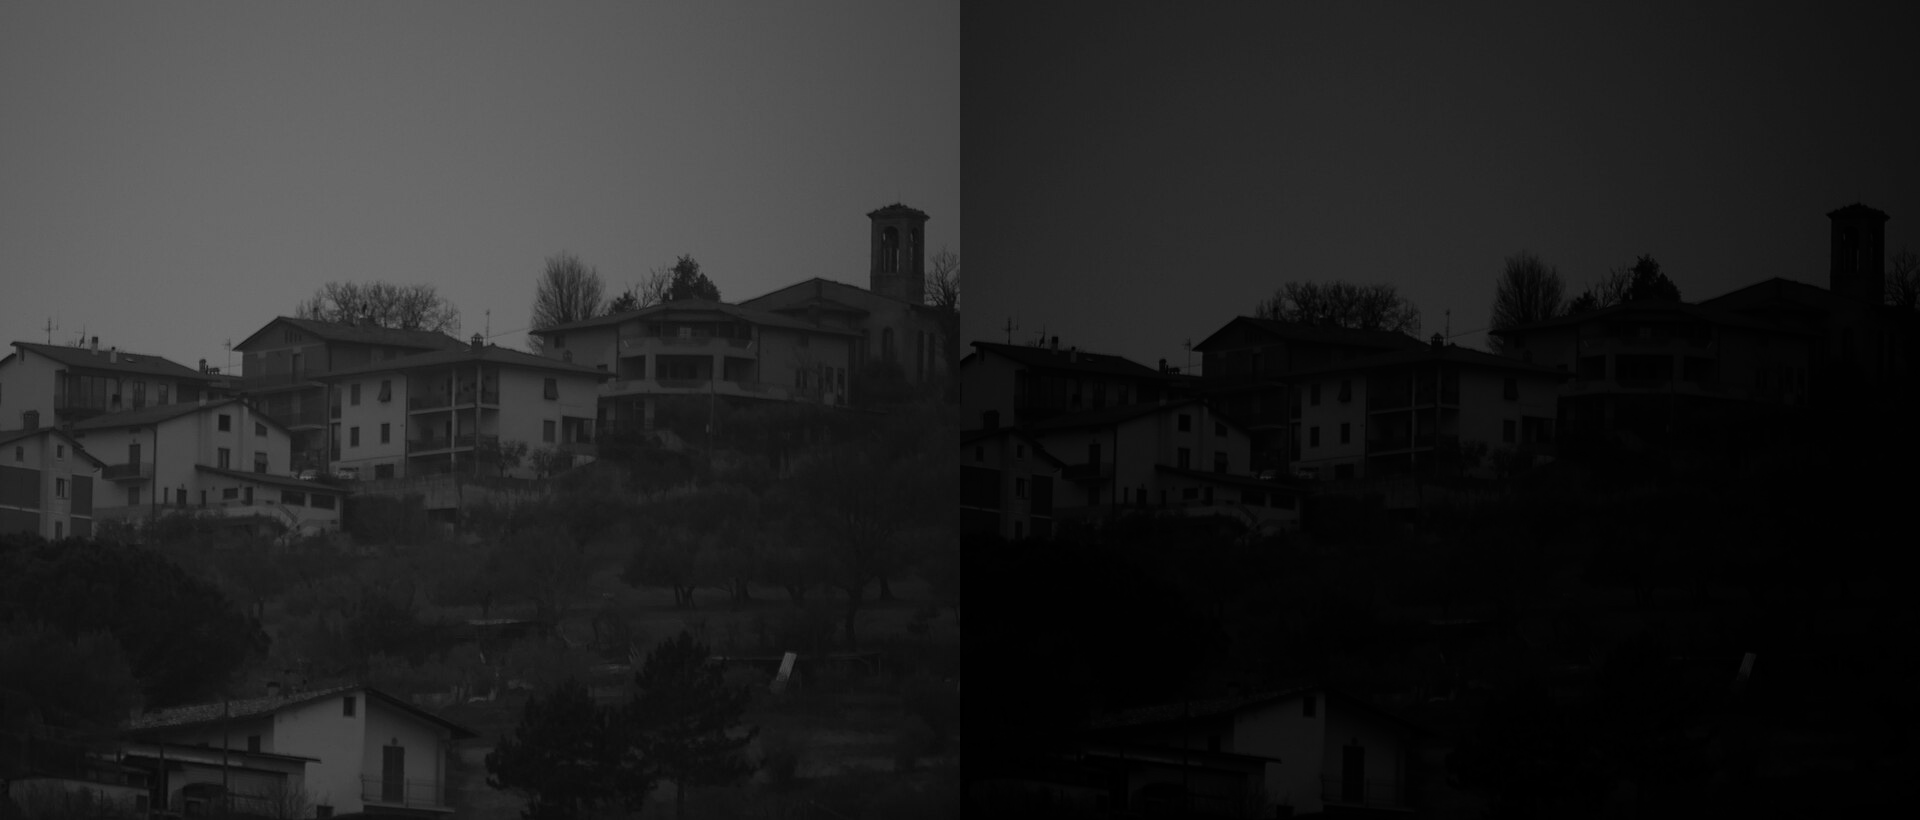

In [ ]:
img = cv.imread('/content/drive/MyDrive/Images/houses.jpg', 0)

try:
    gamma = float(input('Masukkan nilai Gamma: '))
    # Normalisasi ke 0-1, pangkatkan dengan 1/gamma, kalikan 255
    gamma_corrected = np.array(255 * (img / 255) ** (1 / gamma), dtype='uint8')

    final_frame = cv.hconcat((img, gamma_corrected))
    cv2_imshow(final_frame)
except ValueError:
    print('Error, not a number')

## 7. Simulasi Image (Bit) Depth

Masukkan bit depth tujuan (1-7): 3


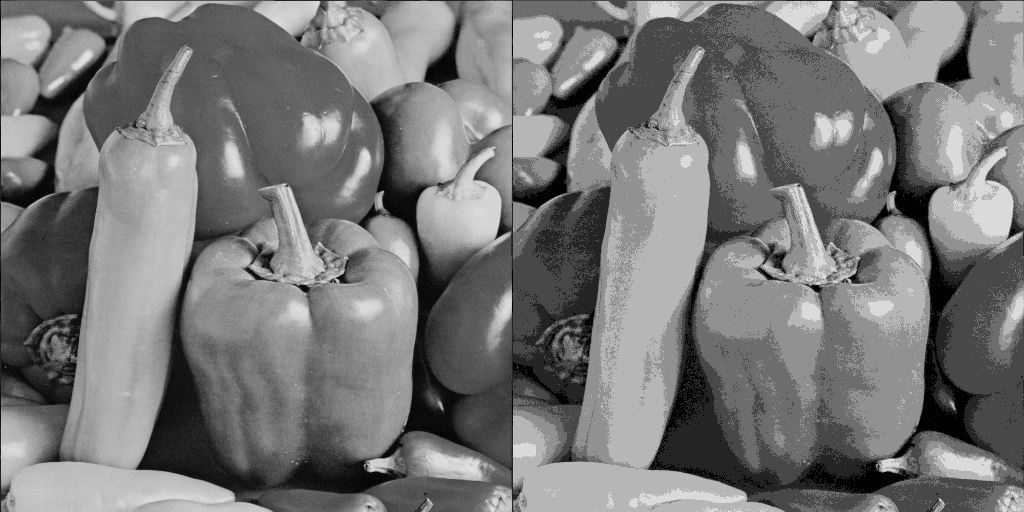

In [ ]:
bit_depth = int(input("Masukkan bit depth tujuan (1-7): "))
level = 255 / (pow(2, bit_depth) - 1)

original = cv.imread('/content/drive/MyDrive/Images/peppers.tiff', cv.IMREAD_GRAYSCALE)
depth_image = np.zeros(original.shape, original.dtype)

# Perhitungan kuantisasi
depth_image = np.round(original / level) * level
depth_image = depth_image.astype(np.uint8)

final_frame = cv.hconcat((original, depth_image))
cv2_imshow(final_frame)

In [ ]:
import cv2 as cv
import numpy as np
import os

# Path disesuaikan persis dengan struktur Drive Anda
path_asli = '/content/drive/MyDrive/Images/galaxy.jpg'
folder_output = '/content/drive/MyDrive/Images/noises/'

if not os.path.exists(folder_output):
    os.makedirs(folder_output)

img = cv.imread(path_asli)

if img is not None:
    mean = 0
    sigma = 25
    print("Sedang men-generate 100 citra noise...")

    for i in range(1, 101):
        gauss = np.random.normal(mean, sigma, img.shape)
        noisy_img = np.clip(img.astype(np.float32) + gauss, 0, 255).astype(np.uint8)

        # Menyimpan dengan nama yang rapi di dalam folder noises
        cv.imwrite(f"{folder_output}noise_{i}.jpg", noisy_img)

    print(f"Berhasil! Silakan cek folder: {folder_output}")
else:
    print(f"Gambar gagal dimuat. Pastikan galaxy.jpg ada di: {path_asli}")

Sedang men-generate 100 citra noise...
Berhasil! Silakan cek folder: /content/drive/MyDrive/Images/noises/


## 8. Average Denoising


---



Jumlah Citra: 10
Nilai PSNR: 19.74 dB


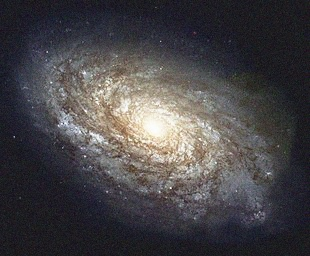

--------------------------------------------------
Jumlah Citra: 20
Nilai PSNR: 19.84 dB


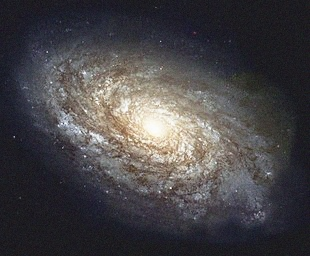

--------------------------------------------------
Jumlah Citra: 40
Nilai PSNR: 19.89 dB


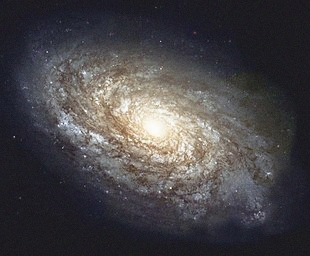

--------------------------------------------------
Jumlah Citra: 80
Nilai PSNR: 19.92 dB


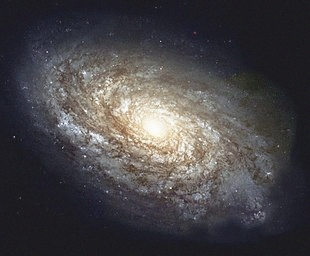

--------------------------------------------------
Jumlah Citra: 100
Nilai PSNR: 19.92 dB


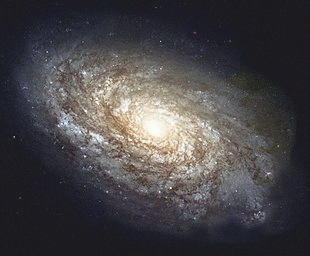

--------------------------------------------------


In [ ]:
import cv2 as cv
import numpy as np
import glob
from google.colab.patches import cv2_imshow

path_asli = '/content/drive/MyDrive/Images/galaxy.jpg'
path_noises = '/content/drive/MyDrive/Images/noises/*.jpg'

original_img = cv.imread(path_asli)
cv_img = []

for img_path in glob.glob(path_noises):
    img = cv.imread(img_path)
    if img is not None:
        cv_img.append(img)

cv_img = np.array(cv_img)
counts = [10, 20, 40, 80, 100]

if len(cv_img) > 0 and original_img is not None:
    for count in counts:
        if count <= len(cv_img):
            # Averaging tanpa perulangan
            avg_img = np.mean(cv_img[:count], axis=0).astype(np.uint8)

            # Hitung PSNR
            psnr = cv.PSNR(original_img, avg_img)

            print(f"Jumlah Citra: {count}")
            print(f"Nilai PSNR: {psnr:.2f} dB")
            cv2_imshow(avg_img)
            print("-" * 50)
else:
    print("Data tidak lengkap. Pastikan gambar asli dan folder noises sudah terisi.")

## 9. Image Masking (Operasi Logika)

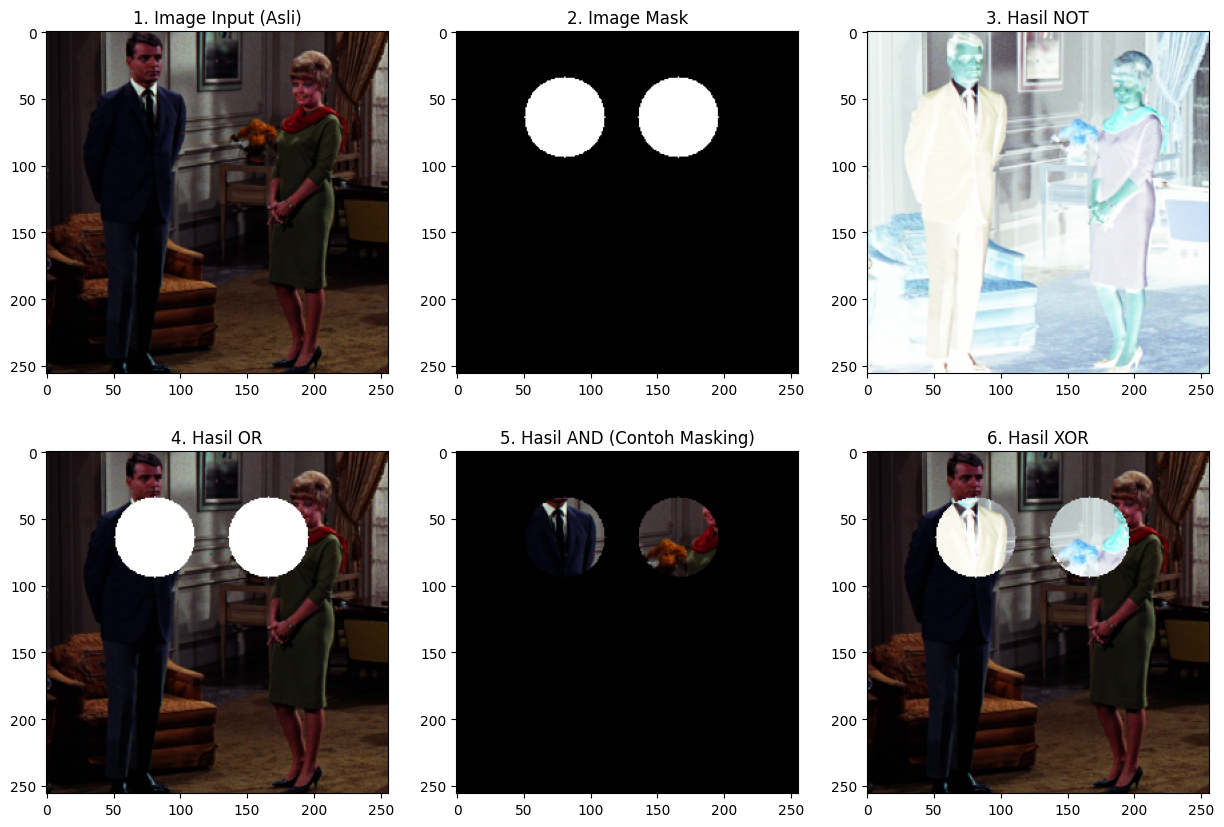

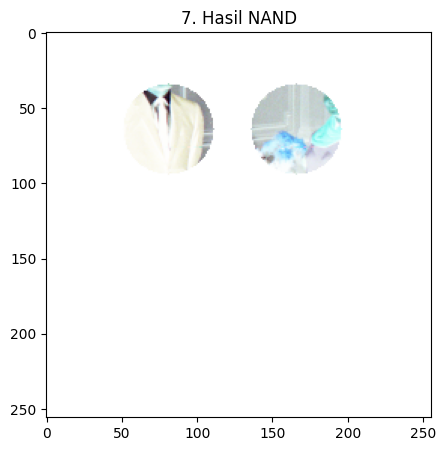

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca citra input
path_gambar = '/content/drive/MyDrive/Images/couple.tiff'
img = cv.imread(path_gambar)

if img is None:
    print(f"Gambar gagal dimuat! Periksa kembali path: {path_gambar}")
else:
    # Konversi BGR ke RGB untuk ditampilkan dengan Matplotlib
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    # 2. Membuat Image Mask (Dua Lingkaran Putih berlatar Hitam)
    # Ukuran mask disamakan dengan ukuran citra input
    h, w = img_rgb.shape[:2]
    mask = np.zeros_like(img_rgb)

    # Membuat dua lingkaran putih (Perkiraan posisi wajah pada citra couple)
    # Format: cv.circle(image, center_coordinate, radius, color, thickness)
    # Radius dan koordinat (x, y) ini bisa Anda sesuaikan agar lebih presisi menutupi wajah
    cv.circle(mask, (int(w * 0.32), int(h * 0.25)), int(h * 0.12), (255, 255, 255), -1) # Kiri
    cv.circle(mask, (int(w * 0.65), int(h * 0.25)), int(h * 0.12), (255, 255, 255), -1) # Kanan

    # 3. Operasi Logika
    # 1. NOT (Hanya membalik nilai citra asli)
    img_not = cv.bitwise_not(img_rgb)

    # 2. OR
    img_or = cv.bitwise_or(img_rgb, mask)

    # 3. AND (Sesuai contoh modul)
    img_and = cv.bitwise_and(img_rgb, mask)

    # 4. NAND (Not AND)
    img_nand = cv.bitwise_not(img_and)

    # 5. XOR (Exclusive OR)
    img_xor = cv.bitwise_xor(img_rgb, mask)

    # 4. Visualisasi Hasil
    plt.figure(figsize=(15, 10))

    # Baris 1: Input dan Mask
    plt.subplot(2, 3, 1), plt.imshow(img_rgb), plt.title('1. Image Input (Asli)')
    plt.subplot(2, 3, 2), plt.imshow(mask), plt.title('2. Image Mask')
    plt.subplot(2, 3, 3), plt.imshow(img_not), plt.title('3. Hasil NOT')

    # Baris 2: Hasil Operasi Logika dengan Mask
    plt.subplot(2, 3, 4), plt.imshow(img_or), plt.title('4. Hasil OR')
    plt.subplot(2, 3, 5), plt.imshow(img_and), plt.title('5. Hasil AND (Contoh Masking)')
    plt.subplot(2, 3, 6), plt.imshow(img_xor), plt.title('6. Hasil XOR')

    # Menampilkan plotting terpisah untuk NAND (karena tempat terbatas di atas)
    plt.figure(figsize=(5, 5))
    plt.imshow(img_nand), plt.title('7. Hasil NAND')

    plt.show()

Analisa untuk Laporan:
- AND: Berguna memotong objek utama (foreground), piksel di luar mask menjadi hitam.
- OR: Menggabungkan citra, area putih pada mask akan menimpa citra menjadi putih penuh.
- XOR: Area irisan akan menjadi hitam, menyoroti perbedaan antara citra input dan mask.  

## 10. Foto Malam Hari (Analisa)

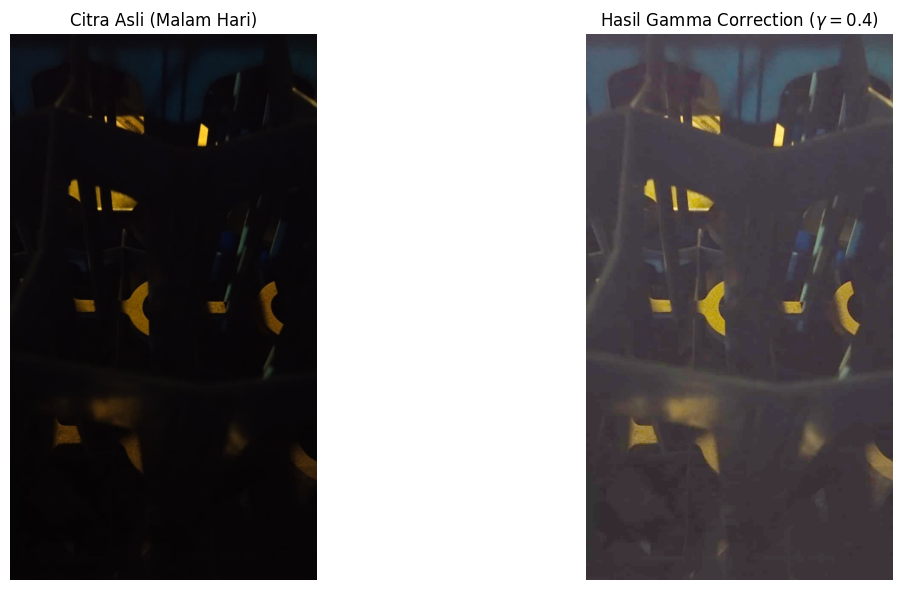

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca citra malam hari
path_gambar = '/content/drive/MyDrive/Images/test gambar.jpeg'
img = cv.imread(path_gambar)

if img is None:
    print(f"Gambar gagal dimuat! Periksa kembali path: {path_gambar}")
else:
    # Konversi warna BGR (OpenCV) ke RGB (Matplotlib)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    # 2. Implementasi Gamma Correction
    # Nilai gamma < 1 akan meregangkan area gelap menjadi lebih terang
    gamma = 0.4

    # Normalisasi piksel ke rentang 0-1, pangkatkan dengan gamma, lalu kembalikan ke 0-255
    # Menggunakan float32 untuk presisi perhitungan sebelum dikembalikan ke uint8
    img_float = img_rgb.astype(np.float32) / 255.0
    gamma_corrected = np.clip(255 * (img_float ** gamma), 0, 255).astype(np.uint8)

    # 3. Visualisasi untuk Laporan
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Citra Asli (Malam Hari)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(gamma_corrected)
    plt.title(f'Hasil Gamma Correction ($\\gamma = {gamma}$)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Untuk foto malam hari yang sangat gelap namun punya sedikit detail, metode Logarithmic Brightness atau Gamma Correction adalah yang paling tepat.
- Alasannya: Metode Log Brightness memetakan rentang sempit dari piksel gelap ke rentang warna yang lebih lebar tanpa membuat area yang sudah terang (seperti lampu jalan) menjadi terlalu silau (washed out).
- Risiko Transformasi Linier Brightness: Jika kita menggunakan Linear Brightness, semua piksel ditambah nilainya. Area yang gelap akan terang, tetapi area yang sudah terang akan melebihi 255 (terkena fungsi truncate), sehingga kehilangan tekstur dan menjadi sekadar blok putih kusam.

## 11. Perbaikan crayfish.jpg

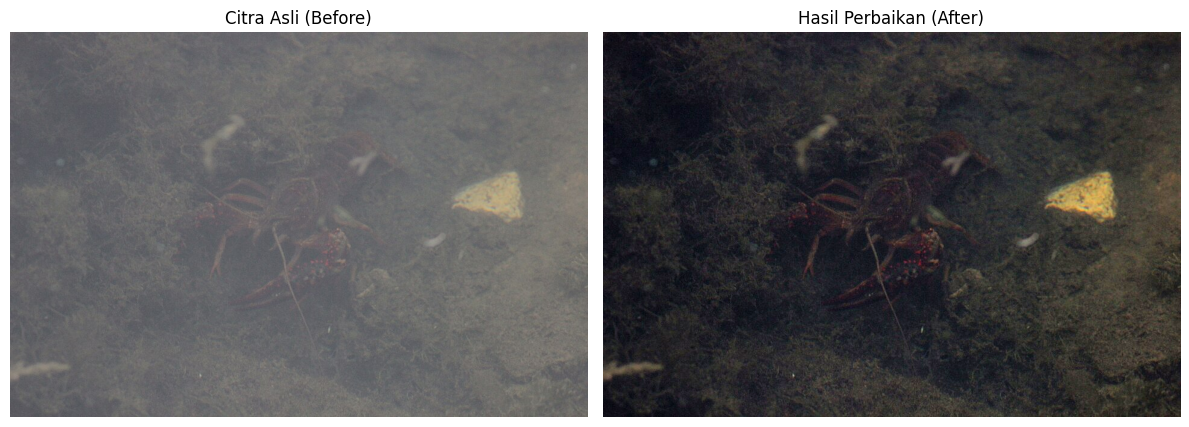

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca citra
path_gambar = '/content/drive/MyDrive/Images/crayfish.jpg'
img = cv.imread(path_gambar)

if img is None:
    print(f"Gambar gagal dimuat! Periksa kembali path: {path_gambar}")
else:
    # Konversi BGR ke RGB untuk Matplotlib
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    # METODE 1: Contrast Stretching (Normalisasi Min-Max)
    # Meregangkan rentang intensitas pixel agar memenuhi range 0-255
    stretched_img = cv.normalize(img_rgb, None, alpha=0, beta=255, norm_type=cv.NORM_MINMAX)

    # METODE 2: Gamma Correction
    # Menyesuaikan mid-tones agar tekstur dan warna lebih tajam
    gamma = 1.2
    img_float = stretched_img.astype(np.float32) / 255.0
    final_img = np.clip(255 * (img_float ** gamma), 0, 255).astype(np.uint8)

    # Menampilkan Visualisasi Before-After
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Citra Asli (Before)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(final_img)
    plt.title(rf'Hasil Perbaikan (After)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Pada gambar yang kontrasnya memudar seperti tertutup kabut (seperti crayfish.jpg), kita butuh meregangkan histogramnya agar nilai gelap menyentuh 0 dan nilai terang menyentuh 255.Metode Pilihan: - Contrast Stretching (atau modifikasi nilai Kontras Linear $a \times f(x) + b$) dipadukan dengan Gamma Correction ringan.
- Alasan: Citra tersebut tergolong citra "Kontras Rendah" dimana kurva histogramnya sempit di tengah. Modifikasi kontras akan melebarkan histogram tersebut sehingga titik paling gelap mendekati hitam pekat